<a href="https://colab.research.google.com/github/yaneladata/Factores-de-Comportamiento-Asociados-al-Ingreso-Anual-en-NovaRetail-/blob/main/notebooks/S8_Student_Version_Project_NovaRetail_Yanela_revisado_iteracion1_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [ ]:
# Importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pointbiserialr
from scipy.stats import chi2_contingency

### Cargar Dataset

In [ ]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [ ]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `ingreso_anual`

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna edad presenta tipo de dato float, sin embargo, la edad es un valor entero (no tiene decimales). La cambiaremos a tipo int.


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [ ]:
# Corregir el tipo de dato
df['edad'] = df['edad'].astype(int)

In [ ]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [ ]:
# Estadísticas descriptivas de variables numéricas
columnas_numericas=["edad", "nivel_ingreso", "visitas_mes", "compras_mes", "gasto_publicidad_dirigida",  "satisfaccion", "ingreso_anual"]
df[columnas_numericas].describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,244.690000


Diagnóstico inicial de variables numéricas

- `edad` — El rango es coherente con una población adulta de comercio electrónico. No presenta anomalía evidente.
- `nivel_ingreso` — Tiene simetría razonable entre la media (30,019.70) y mediana (30,023.75) muy cercanas. Valor mínimo de 8,000 es bajo pero podría ser ingreso mensual en moneda local y el valor max es un dato a validar porque está a ~4.55 std de la media.
- `visitas_mes` — No presenta anomalía estructural. Media (10.03) y mediana (10) prácticamente iguales, simétrica.
- `compras_mes` — Presenta un std (1.10) cercano a la media (1.21), siendo una dispersión relativa alta para una variable de conteo. El percentil 25 es cero, lo que indica que al menos el 25% de los clientes hicieron cero compras en el mes.
- `gasto_publicidad_dirigida` — El máximo (75.51) está a más de 5 std de la media — candidato a revisar outliers en el extremo superior. El mínimo en 0 es esperable (usuarios sin campañas dirigidas asignadas).
- `satisfaccion` — No presenta anomalías en sus datos.
- `ingreso_anual` — Presenta varias anomalías. El min en cero es sospechoso. Puede significar usuarios registrados sin ninguna compra (válido) o un error a la hora de introducir el dato. Media (36,59) y mediana (30,71) presentan una diferencia notable lo que se traduce a una  asimetría positiva marcada (cola hacia la derecha). La std (34,.8) es casi tan grande como la media(36,59). El percentil 25 es cero lo que indica que al menos el 25% de los clientes tienen ingreso_anual = 0.
Esto puede referirse a clientes que realmente no generaron ingreso (válido), y/o posibles errores de carga de datos (a validar).

#### Explorar variables binarias

In [ ]:
# Verificar que cada columna tenga únicamente dos valores posibles

columnas_binarias=["miembro_premium", "abandono"]
df[columnas_binarias].value_counts()


miembro_premium  abandono
0                0           10741
                 1            2170
1                0            1998
                 1              91
dtype: int64

Diagnóstico inicial de variables binarias

- `miembro_premium` — Existe una diferencia notable entre clientes premium(13.93%) y no premium(86.07%)  
- `abandono` — El  15.07% de los clientes abandonan(2261), siendo notable la diferencia con los usuarios que no abandonan(12739) representando el 84.93%. Los clientes no premium(12911) tiene una tasa de abandono(16.81%) más alta que los usuarios premium(2089)(tasa de abandono 4.36%)

#### Explorar variables categóricas

In [ ]:
# Verificar el número de valores únicos por variable categórica
variables_categoricas=["tipo_dispositivo", "region"]
df[variables_categoricas].nunique()

tipo_dispositivo    3
region              4
dtype: int64

In [ ]:
# Explorar variables categóricas y cómo se distribuyen
print(df[variables_categoricas].describe())
for col in variables_categoricas:
    print(col)
    print("frecuencia absoluta:")
    print(df[col].value_counts())
    print("\n Frecuencia Relativa:")
    print(df[col].value_counts(normalize=True))
    print("")




       tipo_dispositivo region
count             15000  15000
unique                3      4
top               móvil  norte
freq               9818   4395
tipo_dispositivo
frecuencia absoluta:
móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64

 Frecuencia Relativa:
móvil         0.654533
escritorio    0.248000
tablet        0.097467
Name: tipo_dispositivo, dtype: float64

region
frecuencia absoluta:
norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64

 Frecuencia Relativa:
norte    0.2930
oeste    0.2540
sur      0.2484
este     0.2046
Name: region, dtype: float64



Diagnóstico inicial de variables categóricas
- `tipo_dispositivo` — distribución coherente entre los dispositivos, el móvil domina ampliamente (~65%), lo cual es consistente con el comportamiento de consumo digital.
- `region`  — distribución bastante balanceada entre las 4 regiones (rango de 20,46% a 29,30%). La región "norte" tiene una ligera sobrerrepresentación, y "este" es la más baja, pero la diferencia (~9 puntos porcentuales entre la mayor y menor) no es alarmante.


### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

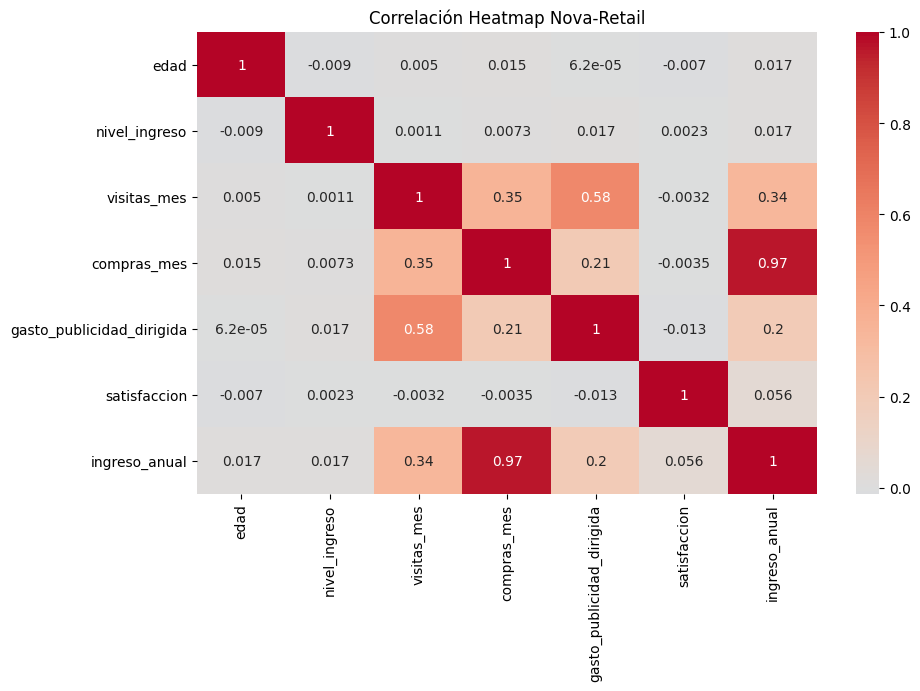

In [ ]:
# Visualizar la matriz de correlación para identificar relaciones
corr=df[columnas_numericas].corr()
plt.figure(figsize = (10,6))
sns.heatmap(corr, annot = True, cmap = "coolwarm", center = 0)
plt.title("Correlación Heatmap Nova-Retail")
plt.show()


Observaciones generales (Heatmap)  
- Se observa una relación muy fuerte entre compras_mes - ingreso_anual de 0.97
- visitas_mes - gasto_publicidad_dirigida es moderada-fuerte de 0.58.
- visitas_mes - ingreso_anual moderada de 0.34.
- visitas_mes - compras_mes moderada de 0.35.
- gasto_publicidad_dirigida - ingreso_anual de 0.20 débil.
- satisfaccion - ingreso_anual de 0.056 prácticamente nula (muy débil).
- nivel_ingreso - ingreso_anual de 0.017 prácticamente nula (muy débil).
- edad - resto de variables de ≤0.02 correlaciones prácticamente nulas en todos los casos.
- satisfaccion - resto de variables	de ≤0.0	nula.

Observaciones respecto a `ingreso_anual`  
- Presenta relación con visitas_mes  moderada de 0.34
-  Con compras_mes presenta una relación muy fuerte de 0.97 , lo que indica asosiación implicando información redundante para el análisis por lo que debemos eliminar una de las dos variables(la que aporte menos información adicional) o combinarlas en una sola variable nueva.


### Scatterplot general

Con 12 variables en el dataset, un scatterplot general (pairplot) generaría una matriz de aproximadamente 66 combinaciones posibles, la mayoría de las cuales mostrarían relaciones débiles o prácticamente nulas según el heatmap de correlación. Generar y revisar visualmente 66 gráficos para extraer valor de solo un puñado de relaciones no es un uso eficiente del análisis.
En su lugar, se priorizó construir scatterplots individuales únicamente para los pares con relación moderada o fuerte identificados en el heatmap.

### Scatterplot para pares clave

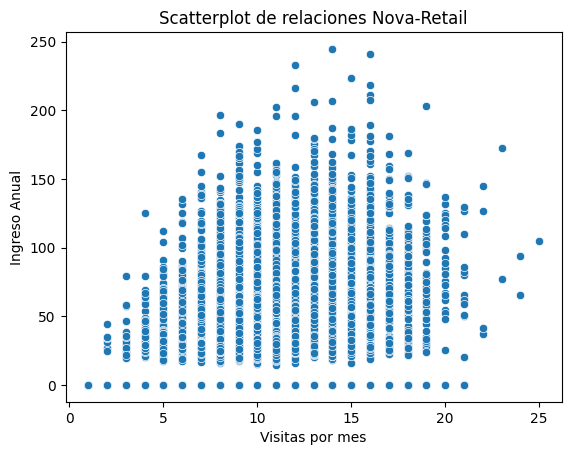

In [ ]:
# Visualizar pares de variables con relaciones moderadas o fuertes

sns.scatterplot(
    data = df,
    x = "visitas_mes",
    y = "ingreso_anual"
)
plt.title("Scatterplot de relaciones Nova-Retail")
plt.xlabel("Visitas por mes")
plt.ylabel("Ingreso Anual")
plt.show()


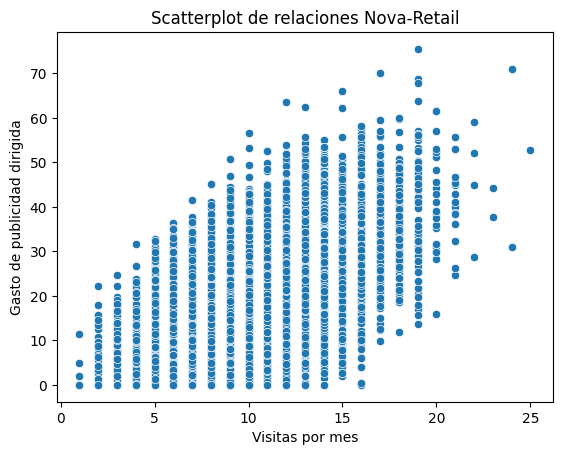

In [ ]:

sns.scatterplot(
    data = df,
    x = "visitas_mes",
    y = "gasto_publicidad_dirigida"
)
plt.title("Scatterplot de relaciones Nova-Retail")
plt.xlabel("Visitas por mes")
plt.ylabel("Gasto de publicidad dirigida")
plt.show()



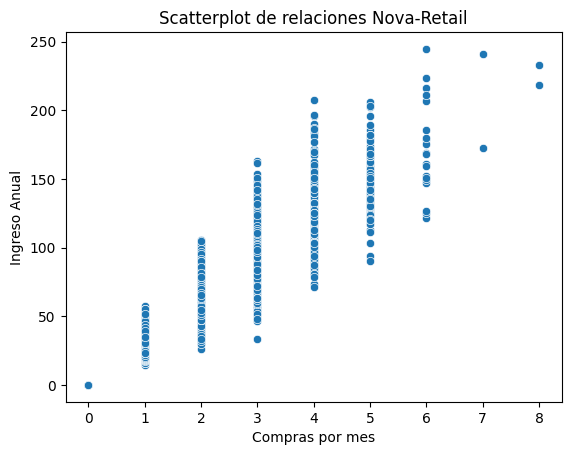

In [ ]:
sns.scatterplot(
    data = df,
    x = "compras_mes",
    y = "ingreso_anual"
)
plt.title("Scatterplot de relaciones Nova-Retail")
plt.xlabel("Compras por mes")
plt.ylabel("Ingreso Anual")
plt.show()

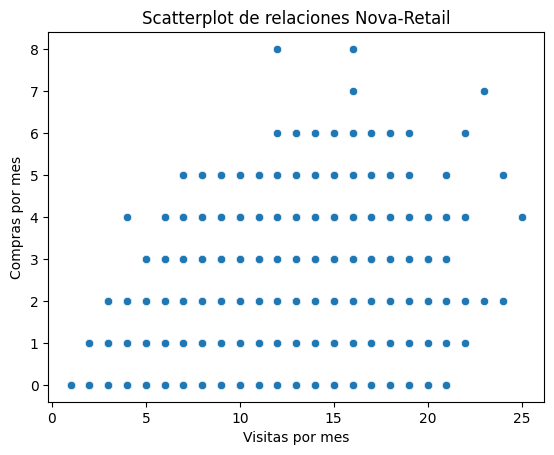

In [ ]:
# Visualizar pares de variables con relaciones moderadas o fuertes

sns.scatterplot(
    data = df,
    x = "visitas_mes",
    y = "compras_mes"
)
plt.title("Scatterplot de relaciones Nova-Retail")
plt.xlabel("Visitas por mes")
plt.ylabel("Compras por mes")
plt.show()



Observaciones iniciales (Scatterplot)

**visitas_mes vs ingreso_anual**
- Dirección positiva
- Dispersión media, presencia de outliers y no hay colinealidad
  
**visitas_mes vs gasto_publicidad_dirigida**
- Dirección positiva
- Dispersión media, presencia de outliers y correlación moderada
  

**compras_mes vs ingreso_anual**
- Dirección positiva
- Dispersión media, presencia de outliers y correlación fuerte

**visitas_mes vs compras_mes**
- Dirección positiva
- Dispersión creciente conforme aumentan las visitas (más concentrado en visitas bajas, más disperso en visitas altas), presencia de algunos outliers, correlación moderada
  

In [ ]:

# Calcular correlación entre variables relevantes
df['visitas_mes'].corr(df['ingreso_anual'], method='pearson')


0.3371466432498745

In [ ]:
# Calcular correlación entre variables relevantes
df['visitas_mes'].corr(df['ingreso_anual'], method='spearman')

0.32095369737696483

Observaciones de correlación

La correlación entre visitas_mes  e  ingreso_anual fue analizada mediante los métodos Pearson (r = 0.337) y Spearman (r = 0.329), obteniendo resultados similares, lo que indica una relación con dirección positiva, de magnitud moderada sin colinealidad.



### Punto-biserial

In [ ]:
# Calcular correlación entre variables relevantes
pointbiserialr(df["miembro_premium"], df["ingreso_anual"])


SignificanceResult(statistic=0.0930994396198015, pvalue=3.0943076155242597e-30)

In [ ]:
# Calcular correlación entre variables relevantes
pointbiserialr(df["abandono"], df["ingreso_anual"])

SignificanceResult(statistic=-0.002823934021617148, pvalue=0.7294691719078393)

Observaciones Punto-biserial

**miembro_premium vs ingreso_anual**
- Relación ligeramente positiva, magnitud baja, p-value < 0.05, indica que el resultado es estadísticamente significativo, es decir, poco probable que se deba al azar.

**abandono vs ingreso_anual**
- Relación ligeramente negativa, magnitud muy baja (cercana a cero). p-value > 0.05 indica que no podemos descartar que esta relación se deba al azar, por lo que no es un resultado estadísticamente significativo y no debe usarse como base para conclusiones.



### V de Cramér

In [ ]:
# Función para calcular V de Cramér
tabla = pd.crosstab(df["region"], df["tipo_dispositivo"])

In [ ]:
# Aplicar V de Cramér en variables relevantes
chi2,p,dof,expected=chi2_contingency(tabla)
chi2
n = tabla.sum().sum()
cramers_v = np.sqrt(chi2/(n*(min(tabla.shape)-1)))
cramers_v, p


(0.012378338407739397, 0.5964767124605646)

Observaciones V de Cramér

La asociación entre región y tipo de dispositivo es muy débil(0.0123), no hay un patrón claro entre categorías. El valor p-value = 0.59 > 0.05 por lo que no podemos confiar en este resultado.


## - Interpretación de resultados para el negocio



### Hallazgo 1 —La correlación entre compras_mes e ingreso_anual de 0.97 es muy fuerte.

**Evidencia visual:**  
Scatterplot entre compras_mes e ingreso_anual de 0.97. Dirección positiva, dispersión baja(los puntos siguen una línea casi recta), presencia de algunos outliers y correlación fuerte.    

**Evidencia numérica:**

El valor de la correlación es 0.97.

**Interpretación**  
Ambas variables se mueven juntas de forma casi perfecta, cuando una sube, la otra sube casi en la misma proporción.

**No podemos afirmar**  
No podemos afirmar que compras_mes cause a ingreso_anual o viceversa, o una tercera variable puede estar detrás de ambas, o ambas podrían estar derivadas matemáticamente una de la otra dentro del dataset.

**Implicación de negocio**  
El equipo debería enfocarse en segmentar los clientes según compras_mes para identificar si la relación global es homogénea o engañosa, y así reducir la fricción que frena al cliente inactivo, aumentar la frecuencia del medianamente activo y proteger la lealtad del activo, usando incentivos y comunicación ajustados a su nivel real de compra.

### Hallazgo 2 — La relación entre visitas_mes e ingreso_anual es moderada de 0.34


**Evidencia visual:**
Scatterplot visitas_mes e ingreso_anual. Dirección positiva, dispersión media, presencia de outliers y no se observa correlación fuerte con otras variables.


**Evidencia numérica:**
El valor de la correlación es 0.34.

**Interpretación**  
Hay una relación real, pero moderada y con mucha dispersión. No es una relación que se pueda usar para predecir con confianza una variable a partir de la otra.

**No podemos afirmar**  
No podemos afirmar que más visitas garantizan mayor ingreso.

**Implicación de negocio**  
No sería suficiente enfocarse solo en aumentar visitas esperando que eso eleve el ingreso anual, ya que un cliente puede visitar poco  pero gastar mucho por transacción (alto ticket, bajo volumen) y ser más rentable que uno que visita seguido pero gasta poco. Los datos sugieren que compras_mes podría ser una variable más relevante para el aumento del ingreso ya que tiene una fuerte correlación con ingreso anual.


## - Limitaciones y próximos pasos

### **Limitaciones**
- Correlación ≠ causalidad
- Aunque encontramos una relación entre visitas_mes e ingreso_anual, hay que tener cuidado de no sobreinterpretarla. Que dos variables estén correlacionadas no significa que una cause la otra, podría haber otros factores de por medio, como la antigüedad del cliente o el tipo de producto que compra, influyendo en ambas al mismo tiempo.
Además, la correlación que encontramos (0.34) es moderada, así que las visitas solo explican una parte pequeña de por qué varía el ingreso annual entre clientes. El resto probablemente depende de otras variables que todavía no hemos analizado como satisfaccion o nivel_ingreso.
También vale mencionar que este análisis se hizo viendo a todos los clientes juntos, así que es posible que la relación sea más fuerte en algunos grupos (por ejemplo, clientes nuevos) y más débil en otros. Eso no lo sabemos todavía con este análisis.


### **Próximos pasos**

Segmentar clientes por nivel de actividad en compras
- Dividir a los clientes en tres grupos según compras_mes (inactivo, medianamente activo, activo) usando terciles, para verificar si la correlación muy fuerte (0.97) con ingreso_anual se mantiene en todos los segmentos o si está concentrada en un grupo específico.
- Dentro de esos mismos segmentos, revisar también si la correlación moderada entre visitas_mes - ingreso_anual (0.34) cambia de fuerza, para identificar en qué grupo la frecuencia de visitas sí se conecta más con el ingreso.

Analizar el efecto  por segmento de actividad miembro_premium
- En lugar de comparar premium vs. no premium de forma general, conviene mirarlo dentro de cada segmento de actividad (inactivo, medianamente activo, activo). Así podemos ver si el efecto de premium está escondido porque se mezcla con grupos muy distintos entre sí.

Identificar qué variables explican mejor el ingreso_anual
- Ampliar la búsqueda, correlacionando con nivel_ingreso (el ingreso del cliente, no el de la empresa) ya que es candidata fuerte porque hay una hipótesis de negocio clara y directa: clientes con mayor poder adquisitivo probablemente puedan gastar más en general, independientemente de cuántas veces visiten o compren.



